<a href="https://colab.research.google.com/github/dldustj0715/machine_learning/blob/main/week03/wine_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Dataset EDA 실습

이 노트북은 와인(Wine) 데이터를 이용하여 탐색적 데이터 분석(EDA, Exploratory Data Analysis)의 기본 흐름을 실습하기 위한 자료입니다.

붓꽃 EDA 실습과 동일한 흐름으로 와인 데이터의 구조, 품질, 분포, 변수 간 관계, 이상치 등을 확인합니다.

이번 실습에서는 다음 내용을 확인합니다.

1. 데이터 불러오기
2. 데이터 구조 확인
3. 결측치와 중복 데이터 확인
4. 레이블 종류와 개수 확인
5. 기술통계량 확인
6. 클래스별 평균과 표준편차 확인
7. 변수별 분포 확인
8. 클래스별 분포 비교
9. Box Plot과 Violin Plot
10. Pair Plot
11. 상관관계 분석
12. 산점도를 이용한 변수 관계 확인
13. IQR 기반 이상치 탐지
14. 클래스별 평균 비교


In [1]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 1. 필요한 라이브러리 불러오기

`pandas`는 데이터 처리, `numpy`는 수치 계산, `matplotlib`과 `seaborn`은 시각화를 위해 사용합니다.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 2. 데이터 불러오기

아래 경로는 자신의 Google Drive 환경에 맞게 변경합니다.


In [3]:
# 자신의 파일 위치에 맞게 경로를 수정하세요.
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wine.csv")

df


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


## 3. 데이터 구조 확인

데이터가 몇 개의 행과 열로 구성되어 있는지, 어떤 변수가 존재하는지 확인합니다.


In [4]:
print("데이터 크기:", df.shape)

print("\n처음 5개 데이터")
display(df.head())

print("\n변수 이름")
print(df.columns.tolist())

print("\n자료형")
print(df.dtypes)

print("\n데이터 정보")
df.info()


데이터 크기: (178, 14)

처음 5개 데이터


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



변수 이름
['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']

자료형
Wine                      int64
Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int               float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object

데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   As

## 4. 결측치와 중복 데이터 확인

결측치와 중복 데이터가 있는지 확인합니다.


In [5]:
print("변수별 결측치 개수")
print(df.isnull().sum())

print("\n중복 행 개수")
print(df.duplicated().sum())


변수별 결측치 개수
Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

중복 행 개수
0


## 5. 분석 변수 지정

와인 데이터에서 `Wine`은 클래스 레이블이며, 나머지 변수들은 와인의 화학적 특성을 나타내는 연속형 변수입니다.


In [6]:
numeric_cols = [
    'Alcohol',
    'Malic.acid',
    'Ash',
    'Acl',
    'Mg',
    'Phenols',
    'Flavanoids',
    'Nonflavanoid.phenols',
    'Proanth',
    'Color.int',
    'Hue',
    'OD',
    'Proline',
]

target_col = 'Wine'


## 6. 레이블 종류와 개수 확인

각 Wine 클래스의 종류와 데이터 개수를 확인합니다.


In [7]:
print("레이블 종류")
print(df[target_col].unique())

print("\n레이블별 개수")
print(df[target_col].value_counts())


레이블 종류
[1 2 3]

레이블별 개수
Wine
2    71
1    59
3    48
Name: count, dtype: int64


### 레이블 개수 시각화

각 Wine 클래스별 샘플 수를 막대그래프로 확인합니다.


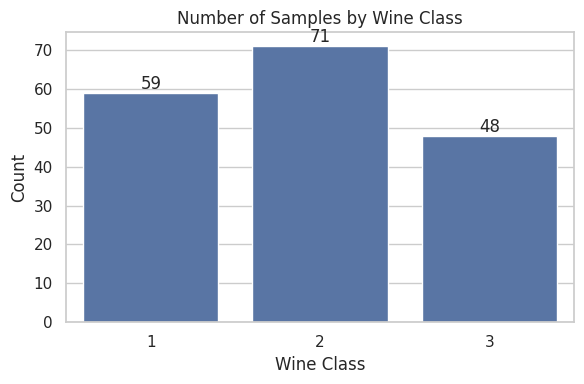

In [8]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x=target_col
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Samples by Wine Class")
plt.xlabel("Wine Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


## 7. 기술통계량 확인

수치형 변수의 평균, 표준편차, 최솟값, 사분위수, 최댓값 등을 확인합니다.


In [9]:
display(df[numeric_cols].describe().round(3))


,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


## 8. 클래스별 평균과 표준편차 확인

Wine 클래스별로 각 변수의 평균과 표준편차를 확인합니다.


In [10]:
print("클래스별 평균")
display(
    df.groupby(target_col)[numeric_cols]
      .mean()
      .round(3)
)

print("클래스별 표준편차")
display(
    df.groupby(target_col)[numeric_cols]
      .std()
      .round(3)
)


클래스별 평균


,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Wine,,,,,,,,,,,,,
1,13.745,2.011,2.456,17.037,106.339,2.840,2.982,0.290,1.899,5.528,1.062,3.158,1115.712
2,12.279,1.933,2.245,20.238,94.549,2.259,2.081,0.364,1.630,3.087,1.056,2.785,519.507
3,13.154,3.334,2.437,21.417,99.312,1.679,0.781,0.448,1.154,7.396,0.683,1.684,629.896


클래스별 표준편차


,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Wine,,,,,,,,,,,,,
1,0.462,0.689,0.227,2.546,10.499,0.339,0.397,0.070,0.412,1.239,0.116,0.357,221.521
2,0.538,1.016,0.315,3.350,16.753,0.545,0.706,0.124,0.602,0.925,0.203,0.497,157.211
3,0.530,1.088,0.185,2.258,10.890,0.357,0.294,0.124,0.409,2.311,0.114,0.272,115.097


## 9. 각 변수의 전체 분포 확인

히스토그램과 KDE 곡선을 이용하여 각 변수의 전체 분포를 확인합니다.


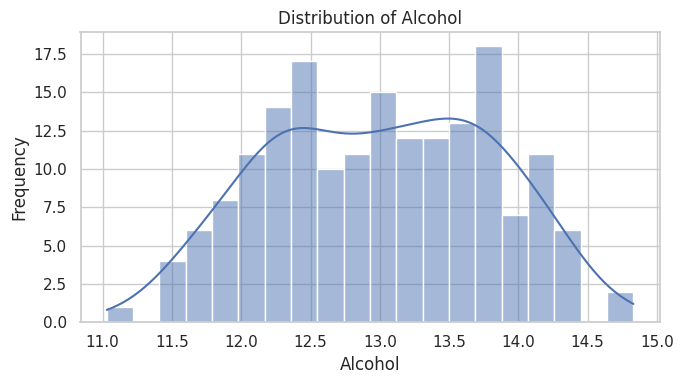

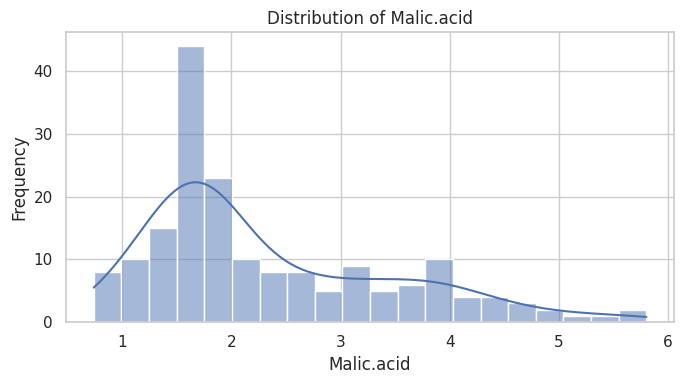

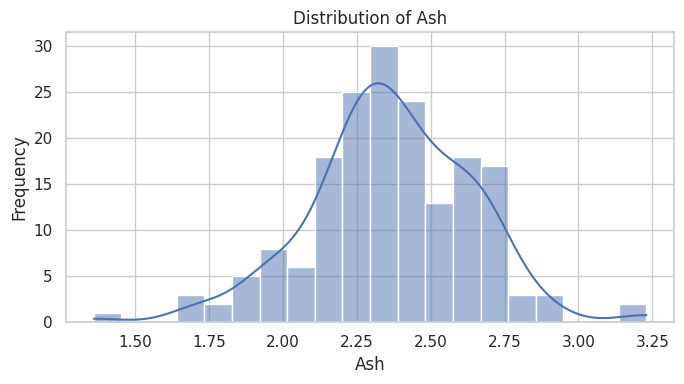

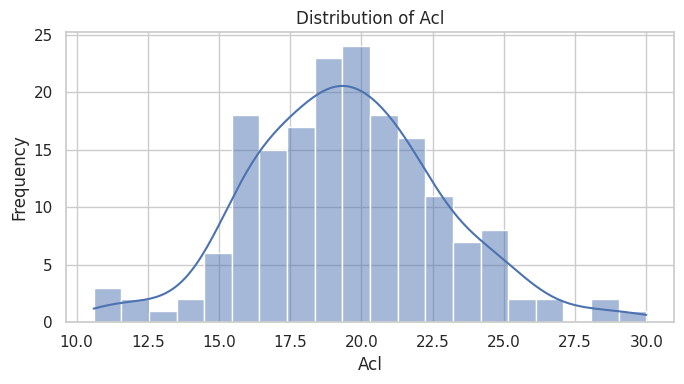

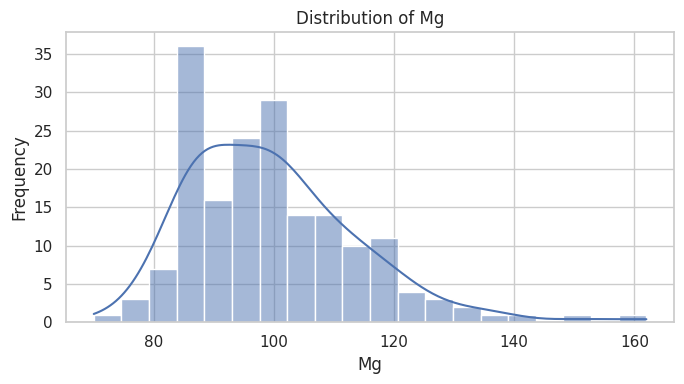

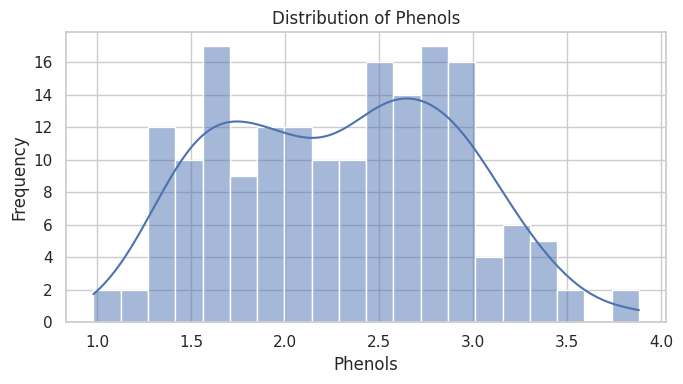

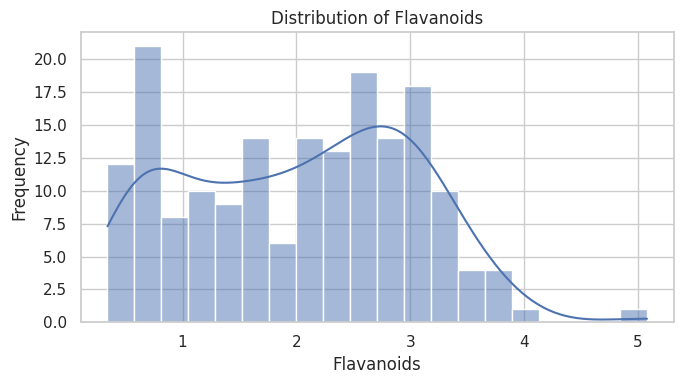

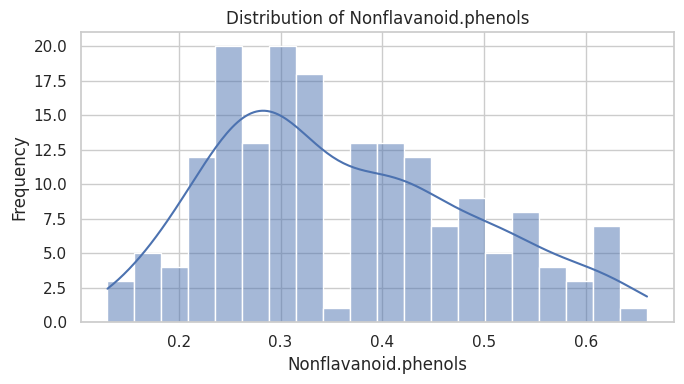

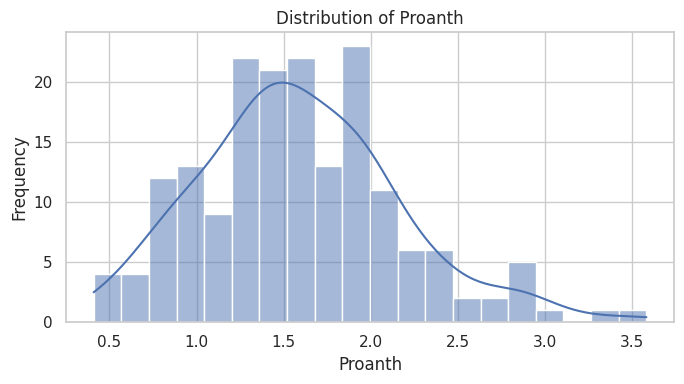

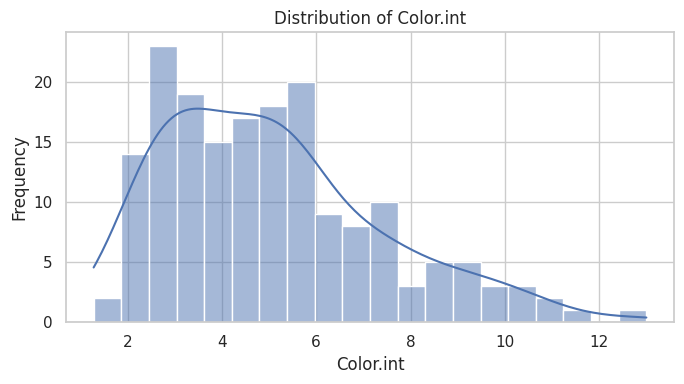

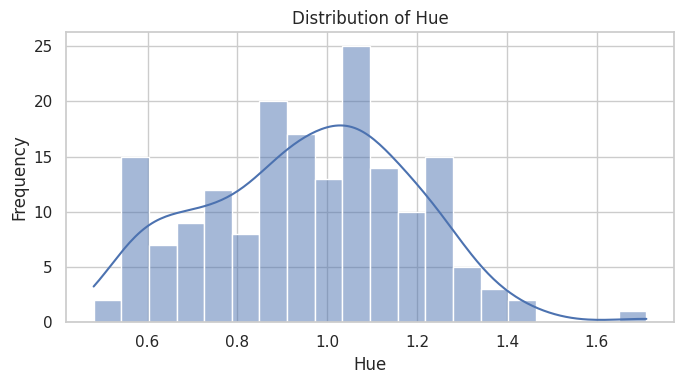

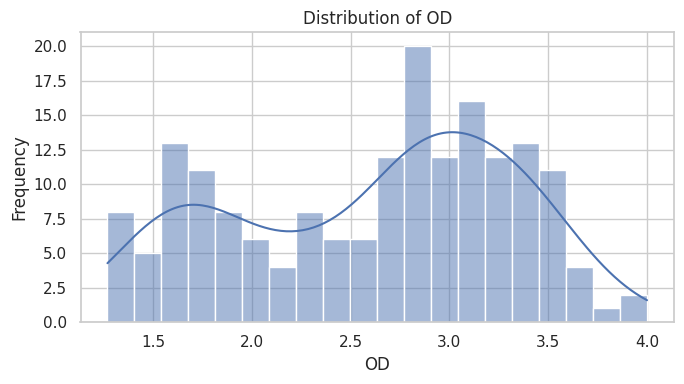

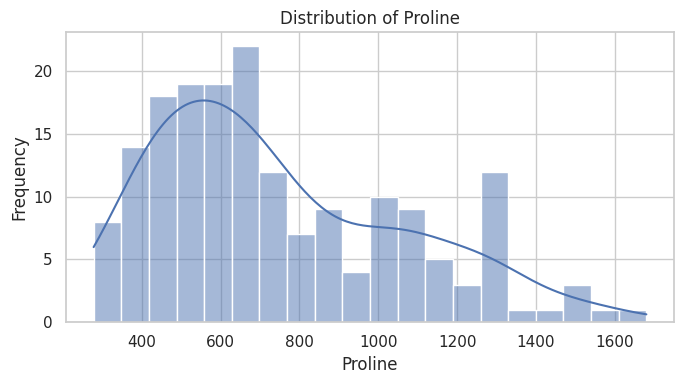

In [11]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


## 10. 클래스별 변수 분포 비교

각 변수에서 Wine 클래스별 분포가 어떻게 다른지 비교합니다.


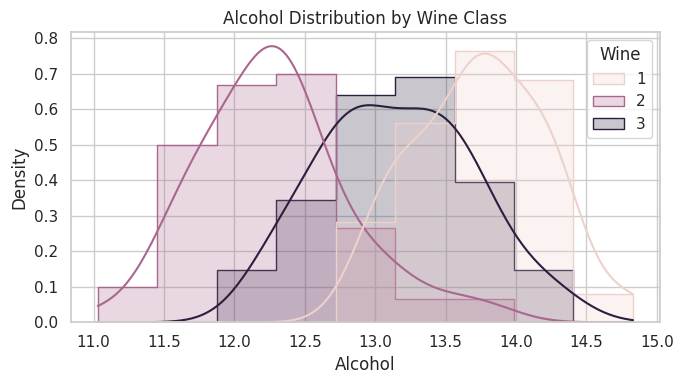

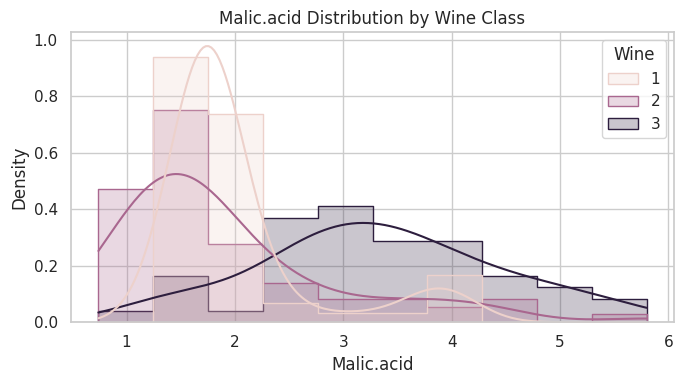

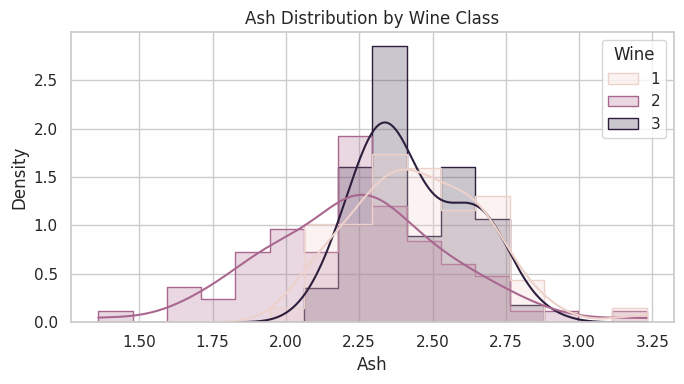

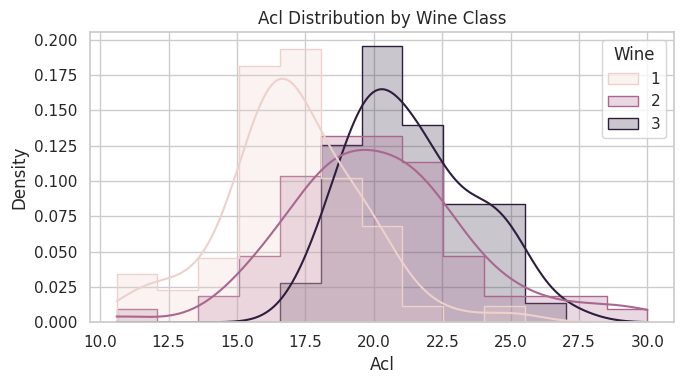

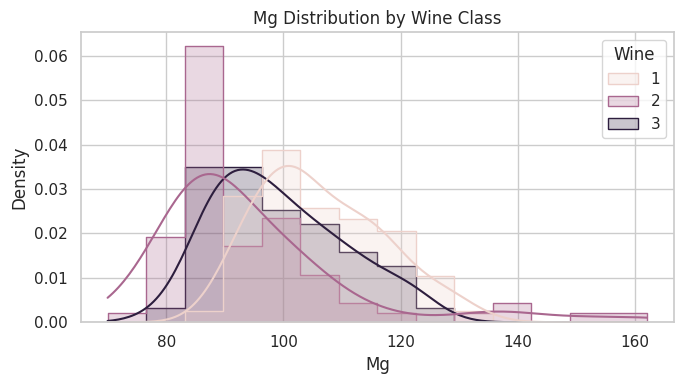

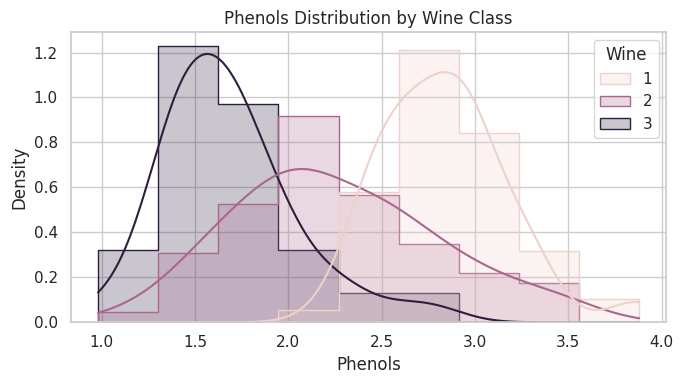

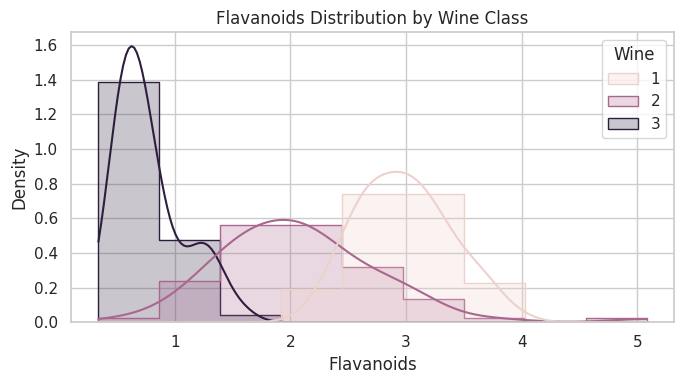

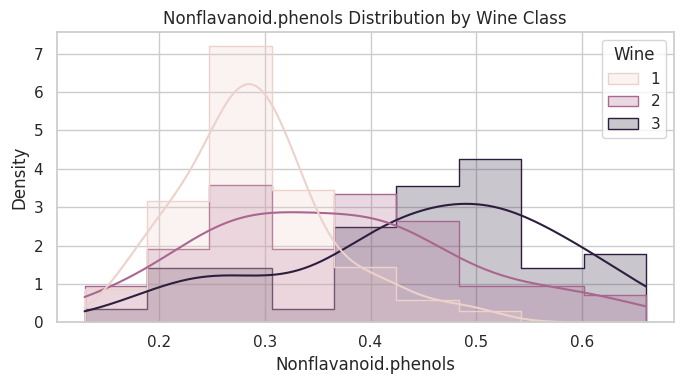

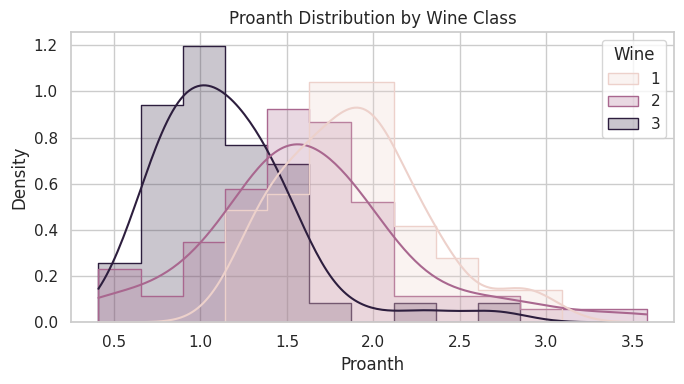

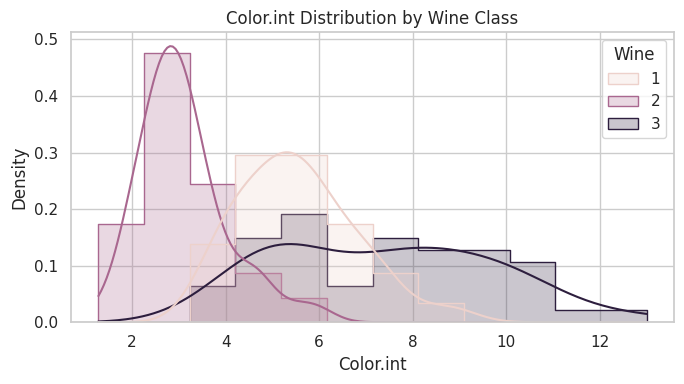

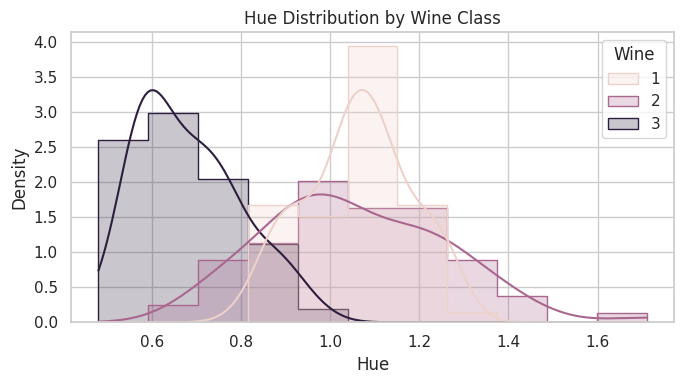

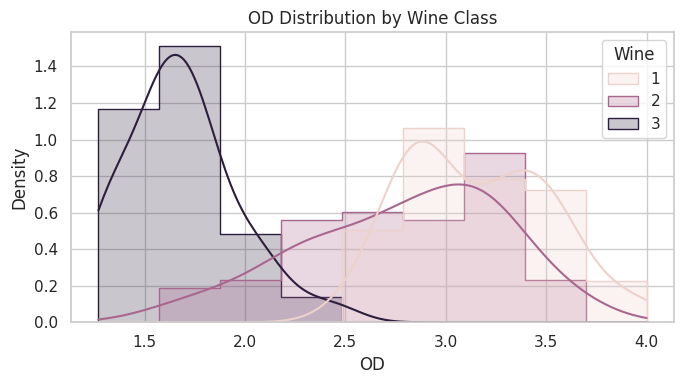

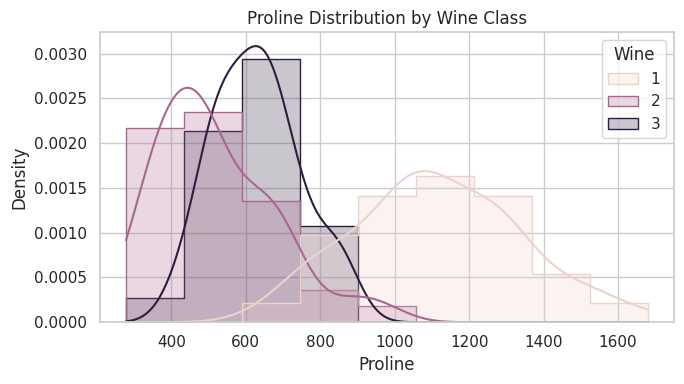

In [12]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"{col} Distribution by Wine Class")

    plt.tight_layout()
    plt.show()


## 11. Box Plot

클래스별 중앙값, 사분위수, 분포 범위와 이상치 후보를 확인합니다.


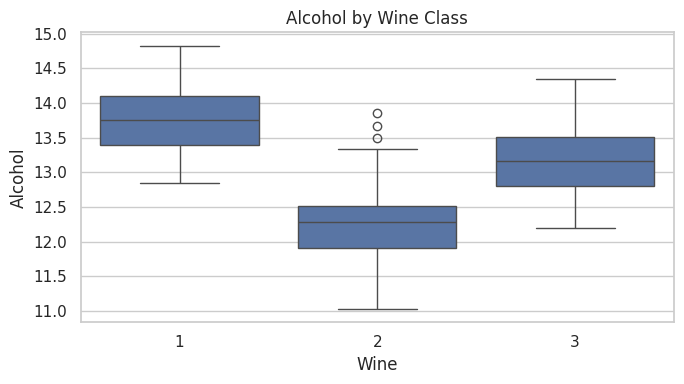

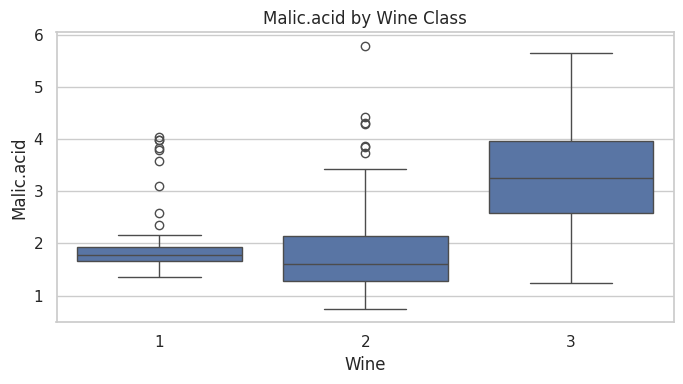

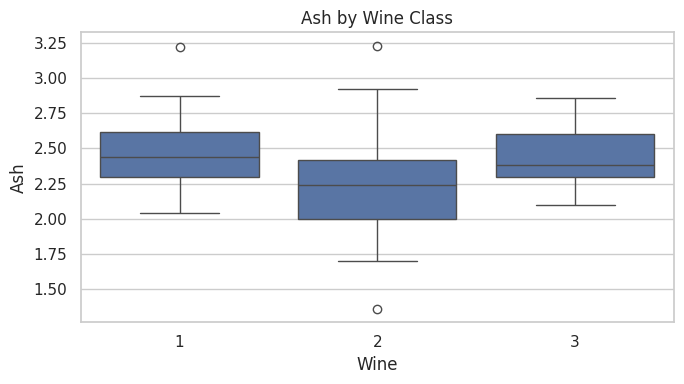

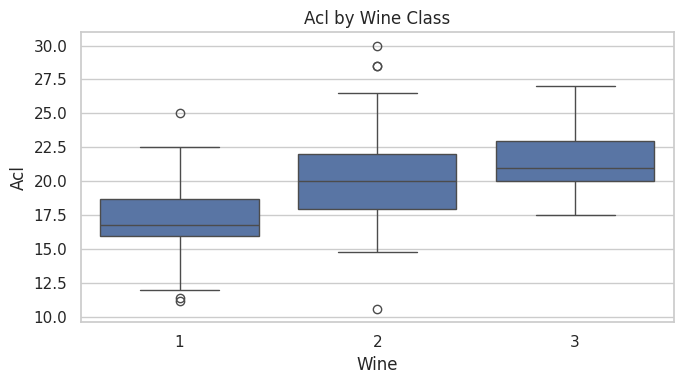

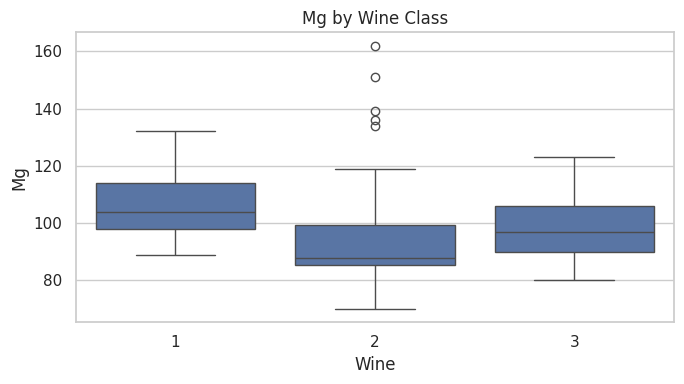

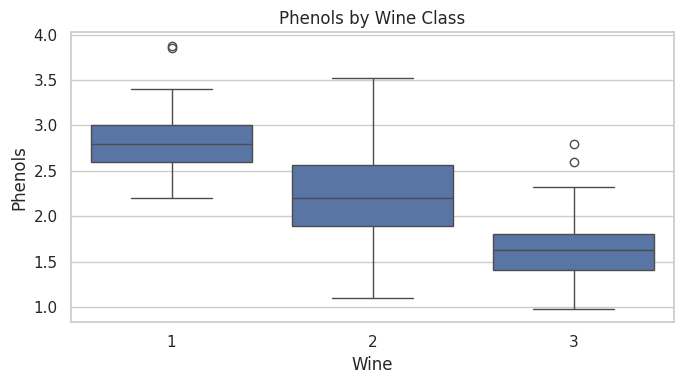

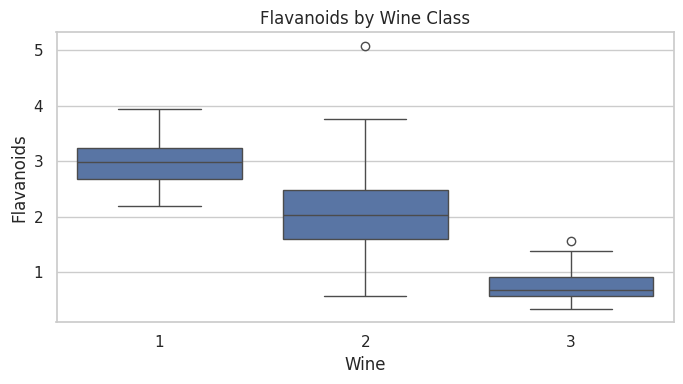

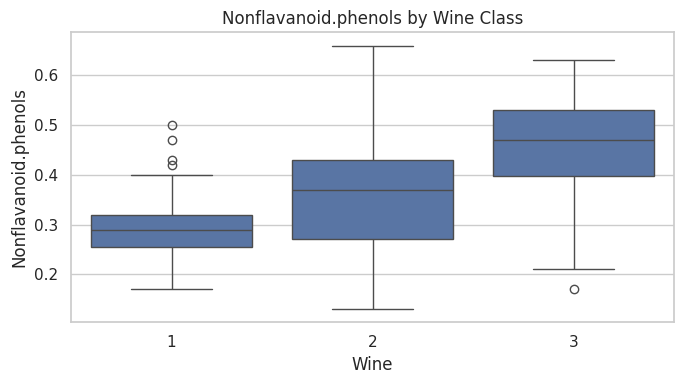

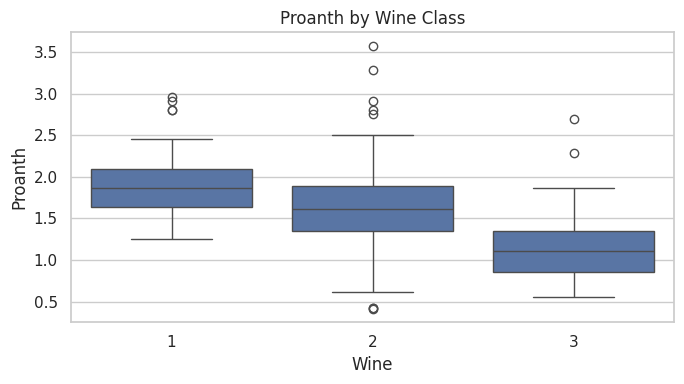

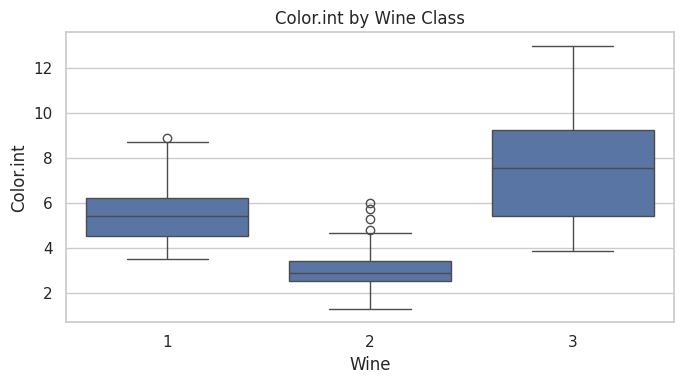

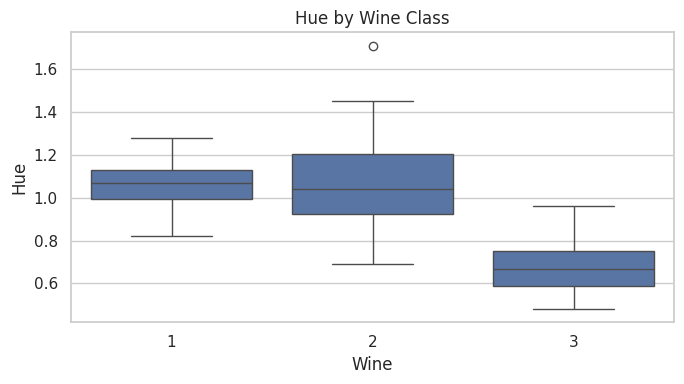

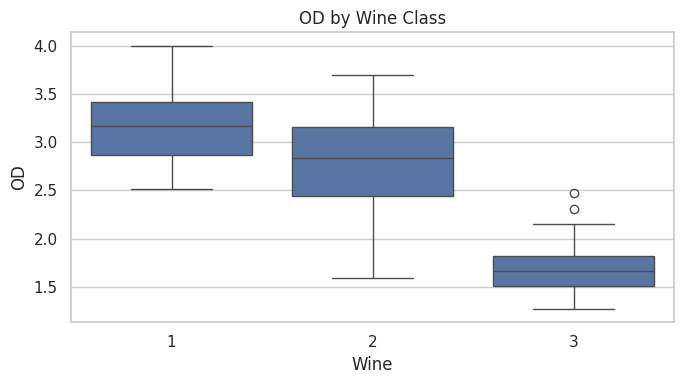

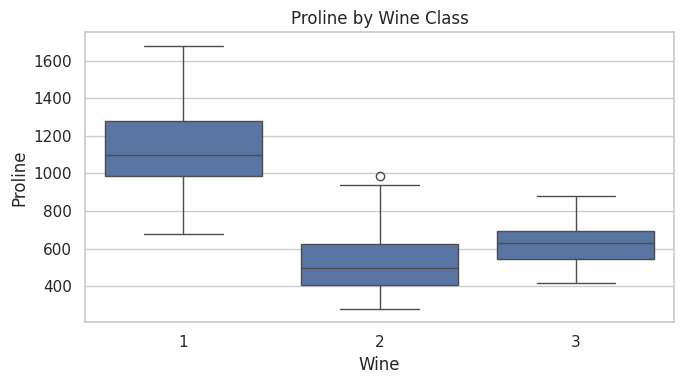

In [13]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x=target_col,
        y=col
    )

    plt.title(f"{col} by Wine Class")

    plt.tight_layout()
    plt.show()


## 12. Violin Plot

클래스별 데이터의 분포와 밀도를 함께 확인합니다.


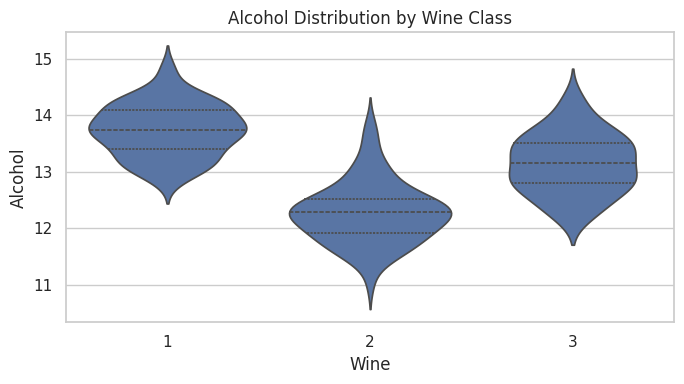

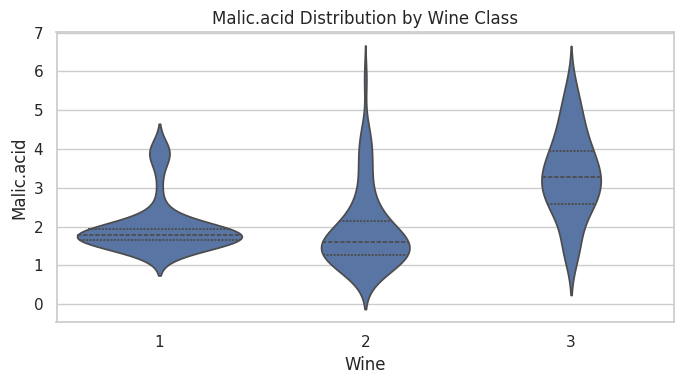

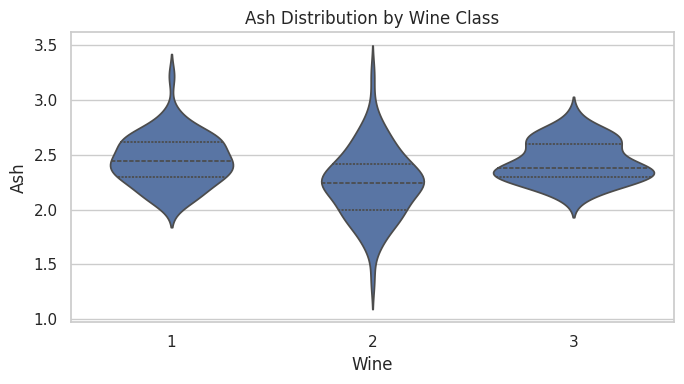

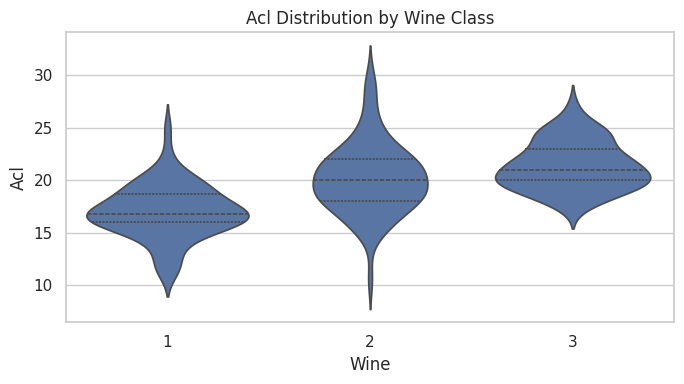

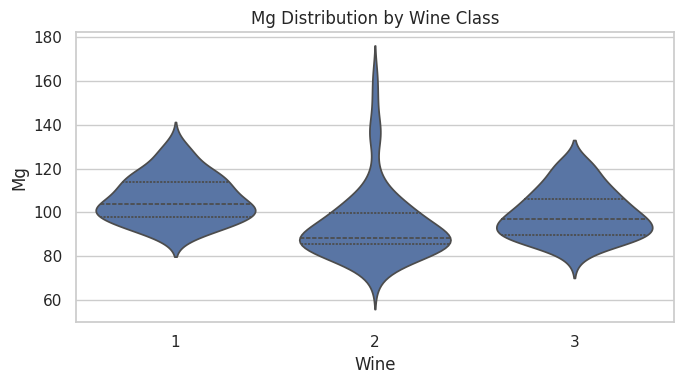

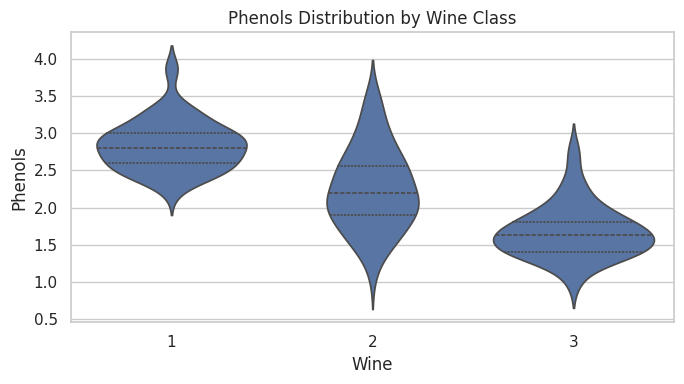

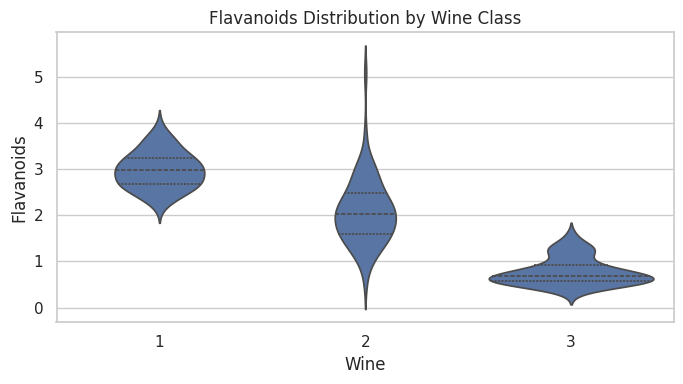

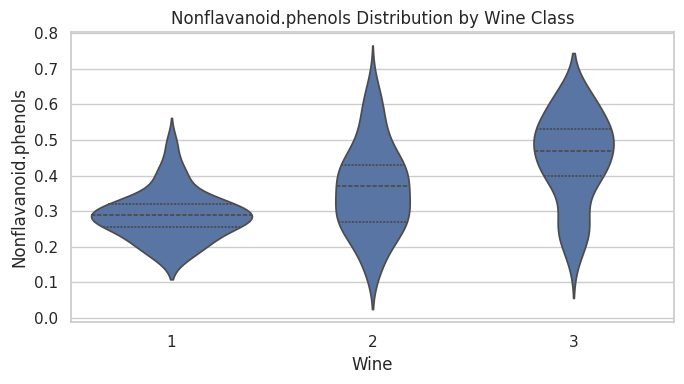

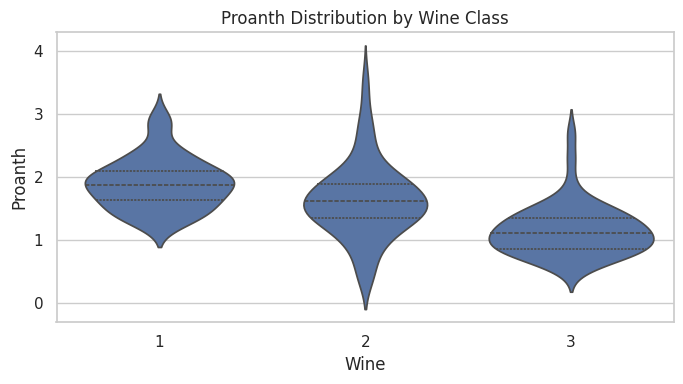

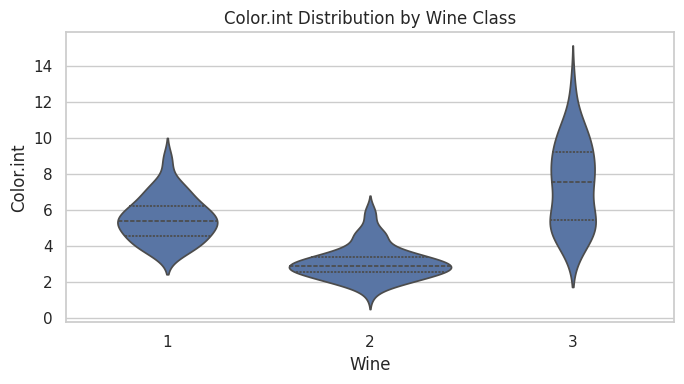

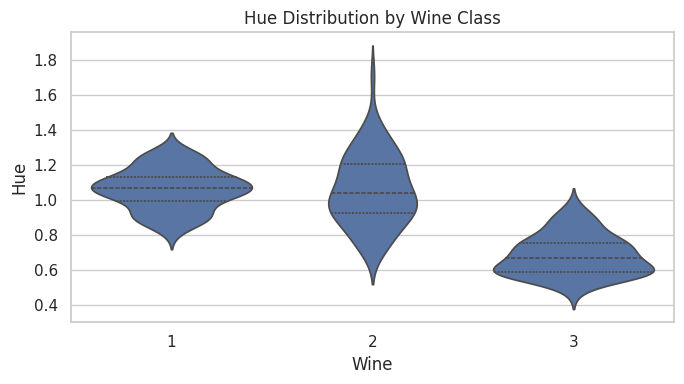

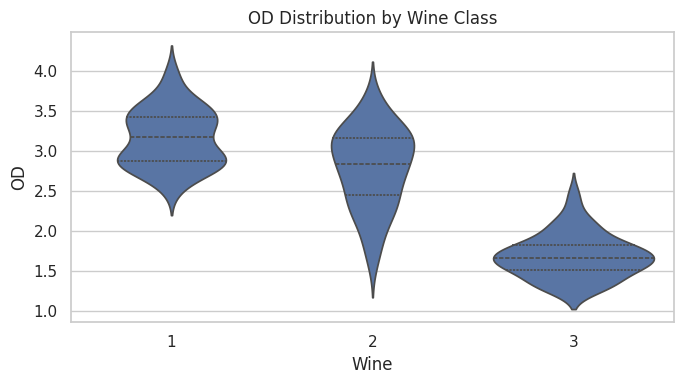

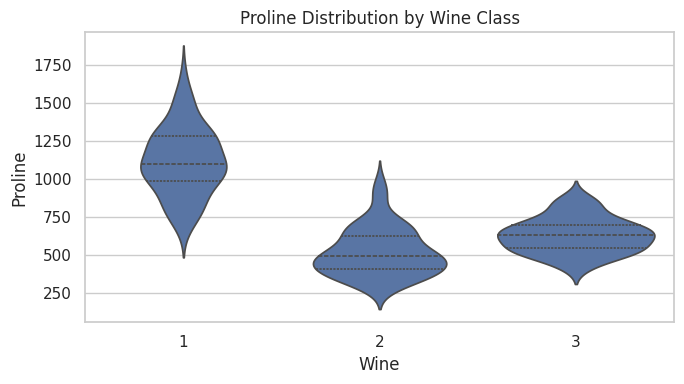

In [14]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.violinplot(
        data=df,
        x=target_col,
        y=col,
        inner="quartile"
    )

    plt.title(f"{col} Distribution by Wine Class")

    plt.tight_layout()
    plt.show()


## 13. Pair Plot

모든 변수를 한 번에 넣으면 그래프가 매우 커지므로, 대표 변수 몇 개를 선택하여 클래스별 분리 정도를 확인합니다.


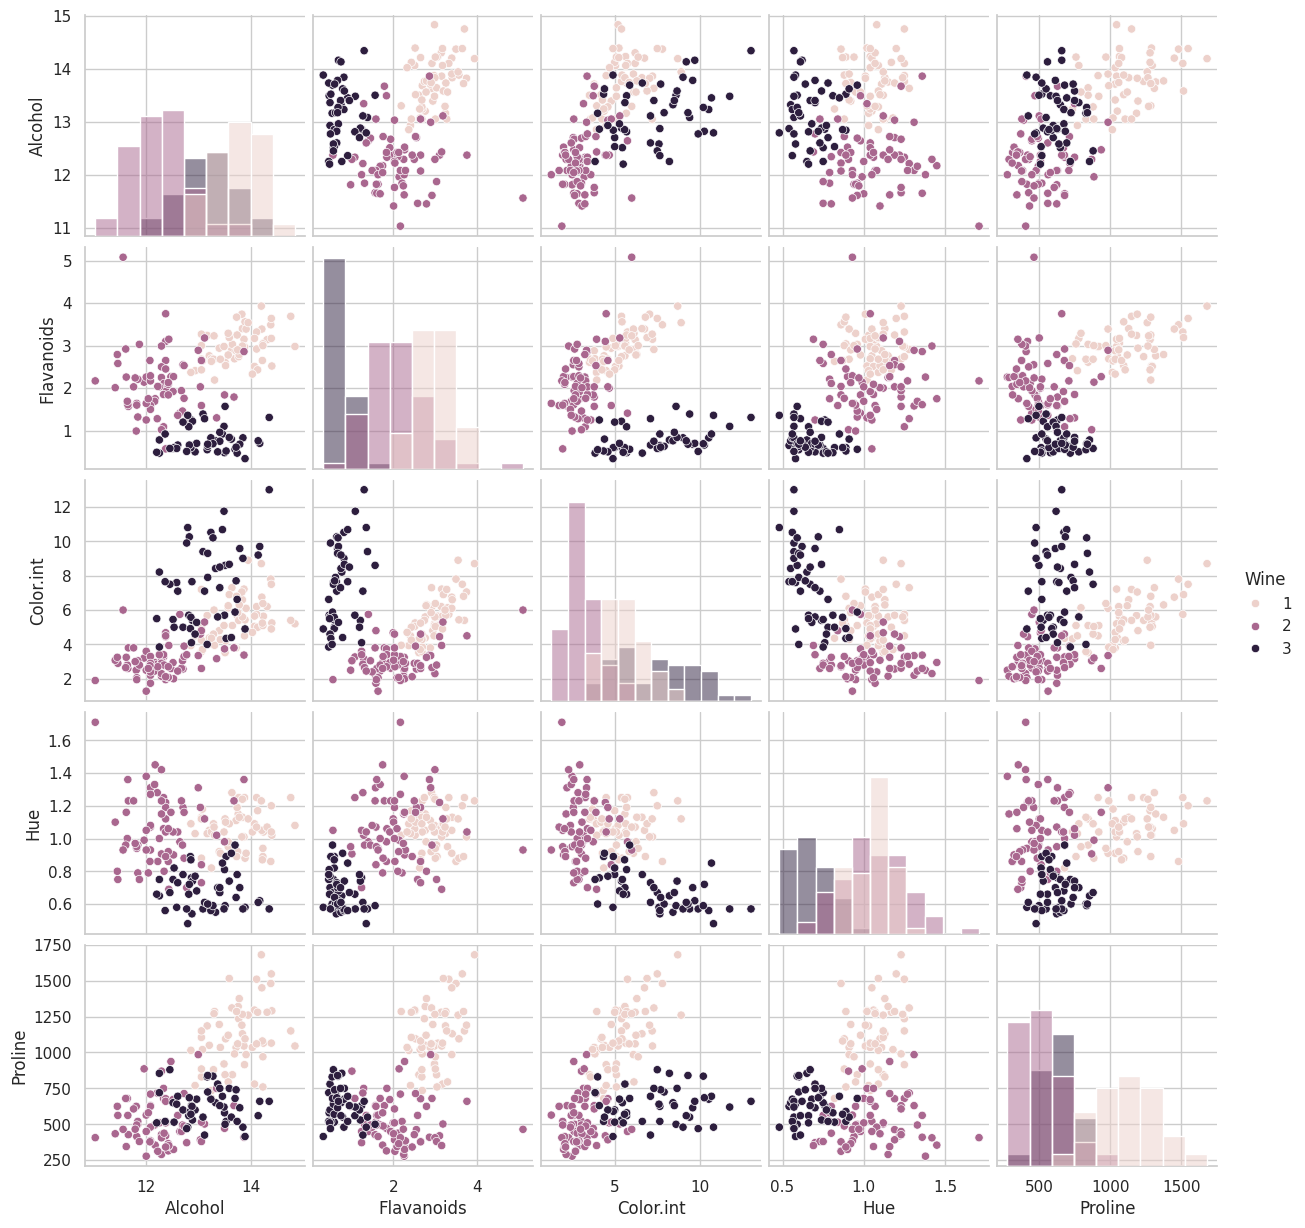

In [15]:
pair_cols = [
    'Alcohol',
    'Flavanoids',
    'Color.int',
    'Hue',
    'Proline'
]

sns.pairplot(
    df,
    vars=pair_cols,
    hue=target_col,
    diag_kind="hist"
)

plt.show()


## 14. 변수 간 상관관계 분석

연속형 변수 사이의 선형적인 상관관계를 확인합니다.


In [16]:
corr = df[numeric_cols].corr()

display(corr.round(3))


,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Alcohol,1.000,0.094,0.212,-0.310,0.271,0.289,0.237,-0.156,0.137,0.546,-0.072,0.072,0.644
Malic.acid,0.094,1.000,0.164,0.289,-0.055,-0.335,-0.411,0.293,-0.221,0.249,-0.561,-0.369,-0.192
Ash,0.212,0.164,1.000,0.443,0.287,0.129,0.115,0.186,0.010,0.259,-0.075,0.004,0.224
Acl,-0.310,0.289,0.443,1.000,-0.083,-0.321,-0.351,0.362,-0.197,0.019,-0.274,-0.277,-0.441
Mg,0.271,-0.055,0.287,-0.083,1.000,0.214,0.196,-0.256,0.236,0.200,0.055,0.066,0.393
Phenols,0.289,-0.335,0.129,-0.321,0.214,1.000,0.865,-0.450,0.612,-0.055,0.434,0.700,0.498
Flavanoids,0.237,-0.411,0.115,-0.351,0.196,0.865,1.000,-0.538,0.653,-0.172,0.543,0.787,0.494
Nonflavanoid.phenols,-0.156,0.293,0.186,0.362,-0.256,-0.450,-0.538,1.000,-0.366,0.139,-0.263,-0.503,-0.311
Proanth,0.137,-0.221,0.010,-0.197,0.236,0.612,0.653,-0.366,1.000,-0.025,0.296,0.519,0.330
Color.int,0.546,0.249,0.259,0.019,0.200,-0.055,-0.172,0.139,-0.025,1.000,-0.522,-0.429,0.316


### 상관관계 Heatmap

Heatmap을 이용해 변수 사이의 상관관계를 시각적으로 비교합니다.


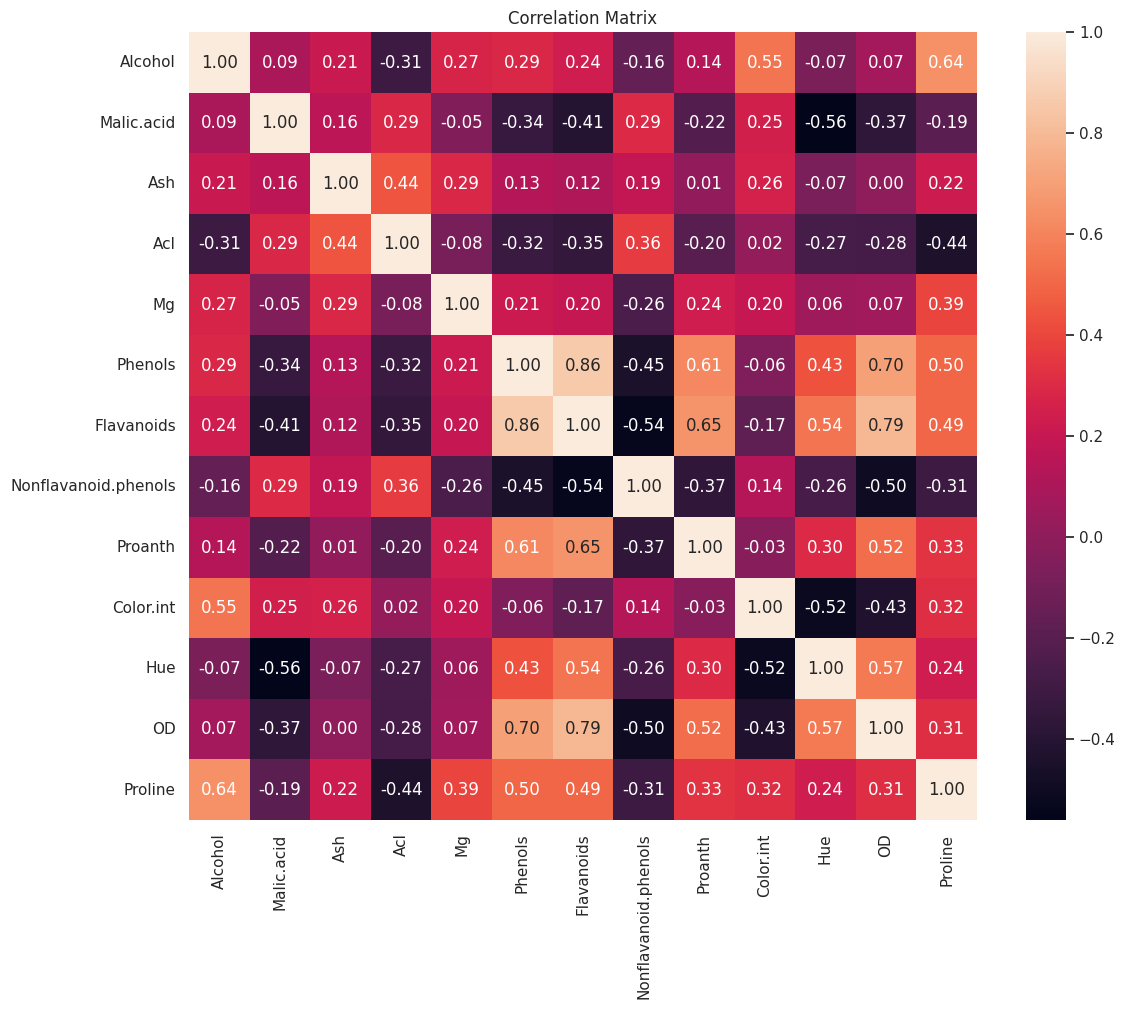

In [17]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()


## 15. Alcohol과 Proline의 관계

두 연속형 변수 사이의 관계를 산점도로 확인하고 Wine 클래스를 색으로 구분합니다.


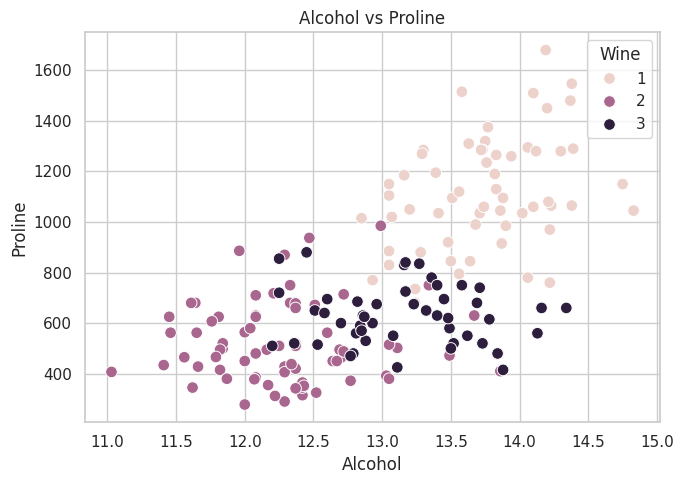

In [18]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='Alcohol',
    y='Proline',
    hue=target_col,
    s=70
)

plt.title("Alcohol vs Proline")
plt.xlabel("Alcohol")
plt.ylabel("Proline")

plt.tight_layout()
plt.show()


## 16. Flavanoids와 Color.int의 관계

Wine 클래스별 분포 차이를 비교하기 위해 또 다른 변수 조합을 확인합니다.


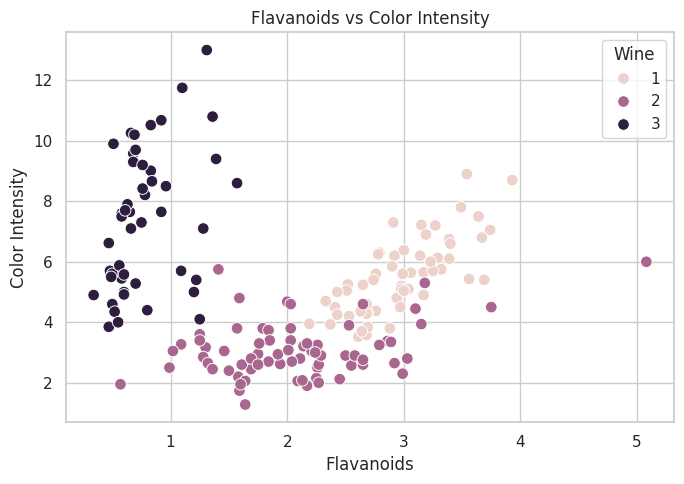

In [19]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='Flavanoids',
    y='Color.int',
    hue=target_col,
    s=70
)

plt.title("Flavanoids vs Color Intensity")
plt.xlabel("Flavanoids")
plt.ylabel("Color Intensity")

plt.tight_layout()
plt.show()


## 17. IQR을 이용한 이상치 탐지

`IQR = Q3 - Q1`을 이용하여 각 변수의 이상치 후보를 확인합니다.


In [20]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        f"{col:25s} : "
        f"{len(outliers)}개 "
        f"(Lower={lower:.2f}, Upper={upper:.2f})"
    )


Alcohol                   : 0개 (Lower=10.39, Upper=15.65)
Malic.acid                : 3개 (Lower=-0.62, Upper=5.30)
Ash                       : 3개 (Lower=1.69, Upper=3.08)
Acl                       : 4개 (Lower=10.75, Upper=27.95)
Mg                        : 4개 (Lower=59.50, Upper=135.50)
Phenols                   : 0개 (Lower=0.16, Upper=4.39)
Flavanoids                : 0개 (Lower=-1.30, Upper=5.38)
Nonflavanoid.phenols      : 0개 (Lower=0.02, Upper=0.69)
Proanth                   : 2개 (Lower=0.20, Upper=3.00)
Color.int                 : 4개 (Lower=-1.25, Upper=10.67)
Hue                       : 1개 (Lower=0.28, Upper=1.63)
OD                        : 0개 (Lower=0.09, Upper=5.02)
Proline                   : 0개 (Lower=-226.25, Upper=1711.75)


### 실제 이상치 데이터 확인

이상치 후보가 있는 경우 해당 값과 Wine 클래스를 함께 확인합니다.


In [21]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    if len(outliers) > 0:
        print(f"\n[{col} 이상치]")
        display(outliers[[col, target_col]])



[Malic.acid 이상치]


,Malic.acid,Wine
123,5.80,2
137,5.51,3
173,5.65,3



[Ash 이상치]


,Ash,Wine
25,3.22,1
59,1.36,2
121,3.23,2



[Acl 이상치]


...

,Proanth,Wine
95,3.28,2
110,3.58,2



[Color.int 이상치]


,Color.int,Wine
151,10.80,3
158,13.00,3
159,11.75,3
166,10.68,3



[Hue 이상치]


,Hue,Wine
115,1.71,2


## 18. 클래스별 평균값 비교

각 Wine 클래스에서 주요 변수의 평균이 어떻게 다른지 비교합니다.


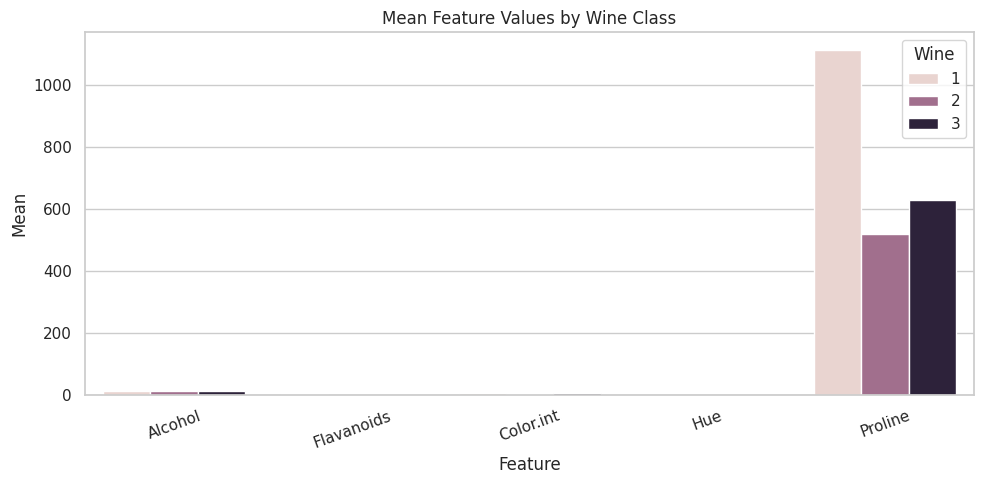

In [22]:
mean_cols = [
    'Alcohol',
    'Flavanoids',
    'Color.int',
    'Hue',
    'Proline'
]

mean_long = (
    df.groupby(target_col)[mean_cols]
      .mean()
      .reset_index()
      .melt(
          id_vars=target_col,
          var_name="Feature",
          value_name="Mean"
      )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=mean_long,
    x="Feature",
    y="Mean",
    hue=target_col
)

plt.title("Mean Feature Values by Wine Class")
plt.xlabel("Feature")
plt.ylabel("Mean")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


## 19. EDA 결과를 어떻게 해석할 것인가

이 실습의 EDA 흐름은 다음과 같습니다.

**데이터 구조 확인 → 데이터 품질 확인 → 레이블 확인 → 기술통계 → 분포 확인 → 클래스별 비교 → 변수 관계 확인 → 상관관계 → 이상치 → 중요한 변수 탐색**

Wine 데이터에서는 각 화학적 특성이 클래스에 따라 얼마나 다르게 분포하는지 확인할 수 있습니다.

EDA 결과를 바탕으로 다음과 같은 질문을 생각할 수 있습니다.

- 어떤 변수가 Wine 클래스를 구분하는 데 가장 유용한가?
- 서로 강하게 상관된 변수가 있는가?
- 이상치가 존재하는 변수는 무엇인가?
- 클래스별 데이터 개수가 크게 차이나는가?
- 몇 개의 주요 변수만으로도 Wine 클래스를 구분할 수 있는가?

즉, EDA는 머신러닝을 수행하기 전에 데이터의 특성을 이해하고 이후 분석 방향을 결정하기 위한 과정입니다.
